**Introduction**

COPD, a chronic lung disease, may cause heavy burden on our healthcare system due to the high re-admission rate of hospitalizaitons. A well-designed prediction model would bring benifits if it could classify patients to the right severity stage of COPD and provide the proper management without delaying treatment. There are some common features that hospitals usually evaluate in patients, including basic patient's information, medical history, several questionnaires, results of lung function tests, and exercise tolerance.

**Attribute information**
1. ID: unique ID
2. AGE: age of the user
3. PackHistory: person’s pack years smoking, where pack years is defined as twenty cigarettes smoked every day for one year
4. COPDSEVERITY: Severity of the disease
5. MWT1: Distance that patient walks in 6 minutes in meters (attempt 1)
6. MWT2: Distance that patient walks in 6 minutes in meters (attempt 2)
7. MWT1Best: Distance that patient walks in 6 minutes in meters (best attempt)
8. FEV1: Amount of air you can force from your lungs in one second in litres. Measure of lung function
9. FEV1PRED: Predicted FEV1
10. FVC: total volume of air that a patient can forcibly exhale in one breath
11. FVCPRED: Predicted FVC
12. CAT: COPD assessment test
13. HAD:  Hospital Anxiety and Depression Scale (HADS)
14. SGRQ: St. George's Respiratory Questionnaire, a Quality of life index. Lower the value, higher the quality of life
15. AGEquartiles: Quartiles of Age
16. copd: Stage of COPD
17. gender: sex of the person. Males are represented by 1, and females are represented by 0.
18. smoking?
19. Diabetes: Having a medical history of diabetes is represented by 1; otherwise, it is represented by 0.
20. muscular? 
21. hypertension: Having a medical history of hypertension is represented by 1; otherwise, it is represented by 0.
22. AtrialFib: Having a medical history of Atrial fibrillation is represented by 1; otherwise, it is represented by 0. 
23. IHD: Having a medical history of ischemic heart disease is represented by 1; otherwise, it is represented by 0.


Import necessary libraries may use

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings   
warnings.filterwarnings('ignore')

Read csv file

In [7]:
review = pd.read_csv("copd_dataset.csv")
review

,Unnamed: 0,ID,AGE,PackHistory,COPDSEVERITY,MWT1,MWT2,MWT1Best,FEV1,FEV1PRED,...,SGRQ,AGEquartiles,copd,gender,smoking,Diabetes,muscular,hypertension,AtrialFib,IHD
0,1,58,77,60.0,SEVERE,120.0,120.0,120.0,1.21,36.0,...,69.55,4,3,1,2,1,0,0,1,0
1,2,57,79,50.0,MODERATE,165.0,176.0,176.0,1.09,56.0,...,44.24,4,2,0,2,1,0,0,1,1
2,3,62,80,11.0,MODERATE,201.0,180.0,201.0,1.52,68.0,...,44.09,4,2,0,2,1,0,0,1,0
3,4,145,56,60.0,VERY SEVERE,210.0,210.0,210.0,0.47,14.0,...,62.04,1,4,1,2,0,0,1,1,0
4,5,136,65,68.0,SEVERE,204.0,210.0,210.0,1.07,42.0,...,75.56,1,3,1,2,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,97,10,68,25.0,MILD,511.0,575.0,575.0,2.70,98.0,...,35.84,2,1,1,2,0,1,0,0,0
97,98,43,75,40.0,MILD,576.0,577.0,577.0,2.90,93.0,...,15.05,3,1,1,2,0,1,0,0,1
98,99,74,68,30.0,MODERATE,468.0,582.0,582.0,1.65,67.0,...,19.70,2,2,0,2,0,0,1,0,0
99,100,108,54,30.0,SEVERE,688.0,699.0,699.0,1.72,44.0,...,20.55,1,3,1,2,0,0,0,0,0


In [8]:
# review.drop(columns=['Unnamed: 0','ID'],inplace=True)

In [9]:
review.head()

,Unnamed: 0,ID,AGE,PackHistory,COPDSEVERITY,MWT1,MWT2,MWT1Best,FEV1,FEV1PRED,...,SGRQ,AGEquartiles,copd,gender,smoking,Diabetes,muscular,hypertension,AtrialFib,IHD
0,1,58,77,60.0,SEVERE,120.0,120.0,120.0,1.21,36.0,...,69.55,4,3,1,2,1,0,0,1,0
1,2,57,79,50.0,MODERATE,165.0,176.0,176.0,1.09,56.0,...,44.24,4,2,0,2,1,0,0,1,1
2,3,62,80,11.0,MODERATE,201.0,180.0,201.0,1.52,68.0,...,44.09,4,2,0,2,1,0,0,1,0
3,4,145,56,60.0,VERY SEVERE,210.0,210.0,210.0,0.47,14.0,...,62.04,1,4,1,2,0,0,1,1,0
4,5,136,65,68.0,SEVERE,204.0,210.0,210.0,1.07,42.0,...,75.56,1,3,1,2,0,1,1,0,0


Select the first column("Unnamed) as index

In [11]:
review.set_index('Unnamed: 0', inplace=True)

Get a summary of the data

In [13]:
review.shape

(101, 23)

In [14]:
review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101 entries, 1 to 101
Data columns (total 23 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            101 non-null    int64  
 1   AGE           101 non-null    int64  
 2   PackHistory   101 non-null    float64
 3   COPDSEVERITY  101 non-null    object 
 4   MWT1          99 non-null     float64
 5   MWT2          100 non-null    float64
 6   MWT1Best      100 non-null    float64
 7   FEV1          101 non-null    float64
 8   FEV1PRED      101 non-null    float64
 9   FVC           101 non-null    float64
 10  FVCPRED       101 non-null    int64  
 11  CAT           101 non-null    int64  
 12  HAD           101 non-null    float64
 13  SGRQ          101 non-null    float64
 14  AGEquartiles  101 non-null    int64  
 15  copd          101 non-null    int64  
 16  gender        101 non-null    int64  
 17  smoking       101 non-null    int64  
 18  Diabetes      101 non-null    int64

To check whether there are any repeated rows in this dataset

In [16]:
review.duplicated().sum()

0

Drop the features that have ambiguous definitions.

In [18]:
columns_to_drop_first = ["HAD", "smoking", "muscular"]
review.drop(columns=columns_to_drop_first, axis=1, inplace=True)

The best result from two times 6-minute walking tests (MWT1Best) is chosen to exclusively represent the patient's exercise tolerance.

In [20]:
columns_to_drop_second = ["MWT1", "MWT2"]
review.drop(columns=columns_to_drop_second, axis=1, inplace=True)

In [21]:
review.describe()

,ID,AGE,PackHistory,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,CAT,SGRQ,AGEquartiles,copd,gender,Diabetes,hypertension,AtrialFib,IHD
count,101.000000,101.00000,101.000000,100.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.00000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,91.405941,70.09901,39.698020,399.110000,1.603762,58.531485,2.954950,86.435644,19.336634,40.185842,2.475248,2.19802,0.643564,0.207921,0.118812,0.198020,0.089109
std,51.516246,7.89874,24.558713,106.550116,0.672763,22.294821,0.976283,21.740016,18.674730,18.239268,1.109901,0.88340,0.481335,0.407844,0.325181,0.400495,0.286322
min,1.000000,44.00000,1.000000,120.000000,0.450000,3.290000,1.140000,27.000000,3.000000,2.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,49.000000,65.00000,20.000000,303.750000,1.100000,42.000000,2.270000,71.000000,12.000000,28.410000,1.000000,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,87.000000,71.00000,36.000000,420.000000,1.600000,60.000000,2.770000,84.000000,18.000000,38.210000,3.000000,2.00000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,143.000000,75.00000,54.000000,465.250000,1.960000,75.000000,3.630000,103.000000,24.000000,55.230000,3.000000,3.00000,1.000000,0.000000,0.000000,0.000000,0.000000
max,169.000000,88.00000,109.000000,699.000000,3.180000,102.000000,5.370000,132.000000,188.000000,77.440000,4.000000,4.00000,1.000000,1.000000,1.000000,1.000000,1.000000


**Explore the data**

Check my target data(need to label)

In [24]:
review.copd.value_counts().sort_index()

copd
1    23
2    43
3    27
4     8
Name: count, dtype: int64

To rule out whether the values in columns "COPDSEVERITY" and "copd" are the same

In [26]:
review["COPDSEVERITY"].unique()

array(['SEVERE', 'MODERATE', 'VERY SEVERE', 'MILD'], dtype=object)

Transform "COPDSEVERITY" into numerical values

In [28]:
severity_to_map = {"MILD": 1, "MODERATE": 2, "SEVERE": 3, "VERY SEVERE": 4}
review["COPDSEVERITY"] = review["COPDSEVERITY"].map(severity_to_map)
comparison = review["COPDSEVERITY"] == review["copd"]
print(comparison.value_counts())

True    101
Name: count, dtype: int64


Make histograms to see the data distribution

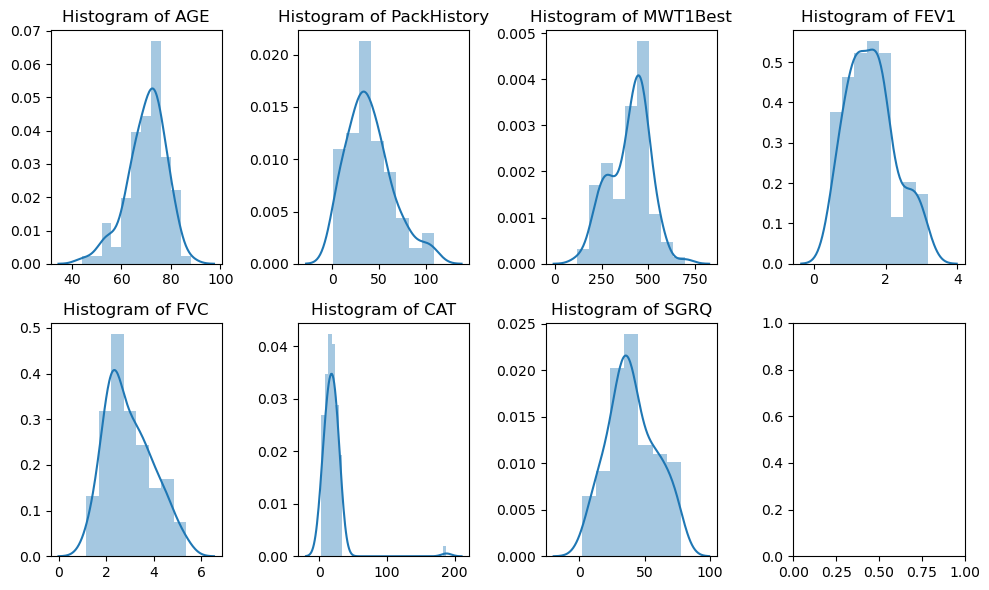

In [30]:
distribution_of_columns = ["AGE", "PackHistory", "MWT1Best", "FEV1", "FVC", "CAT", "SGRQ"]
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
axes = axes.ravel()

for i, feature in enumerate(distribution_of_columns):
    ax = axes[i] 
    sns.distplot(review[feature], ax=ax, kde=True)
    ax.set_title(f'Histogram of {feature}')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

Make a boxplot to check the outliers

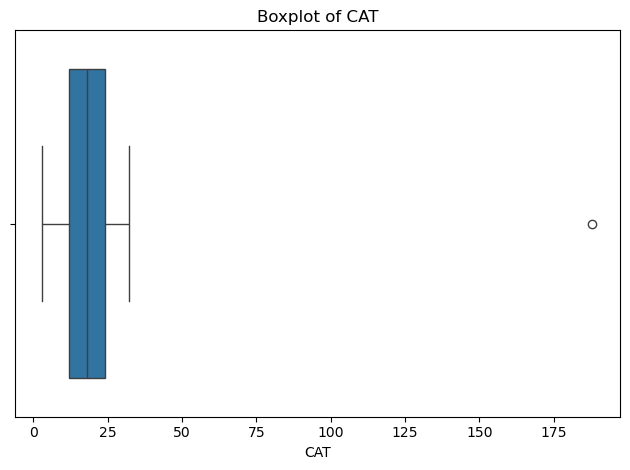

In [32]:
plt_CAT = sns.boxplot(data=review, x="CAT")
plt_CAT.set_title('Boxplot of CAT')
plt_CAT.set_xlabel('CAT')
plt_CAT.set_ylabel('')

plt.tight_layout()
plt.show()

drop the outlier

In [34]:
Q1 = review['CAT'].quantile(0.25)
Q3 = review['CAT'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outlier = review['CAT'] > upper_bound
review_outlier = review[outlier]
review_outlier

,ID,AGE,PackHistory,COPDSEVERITY,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,CAT,SGRQ,AGEquartiles,copd,gender,Diabetes,hypertension,AtrialFib,IHD
Unnamed: 0,,,,,,,,,,,,,,,,,,
61,159,80,3.0,1,451.0,1.97,90.0,2.33,84,188,36.74,4,1,1,0,0,0,0


In [35]:
outlier_row = (review["ID"] == 159)
review = review[~outlier_row]

Make a heatmap for correlation analysis

<Axes: >

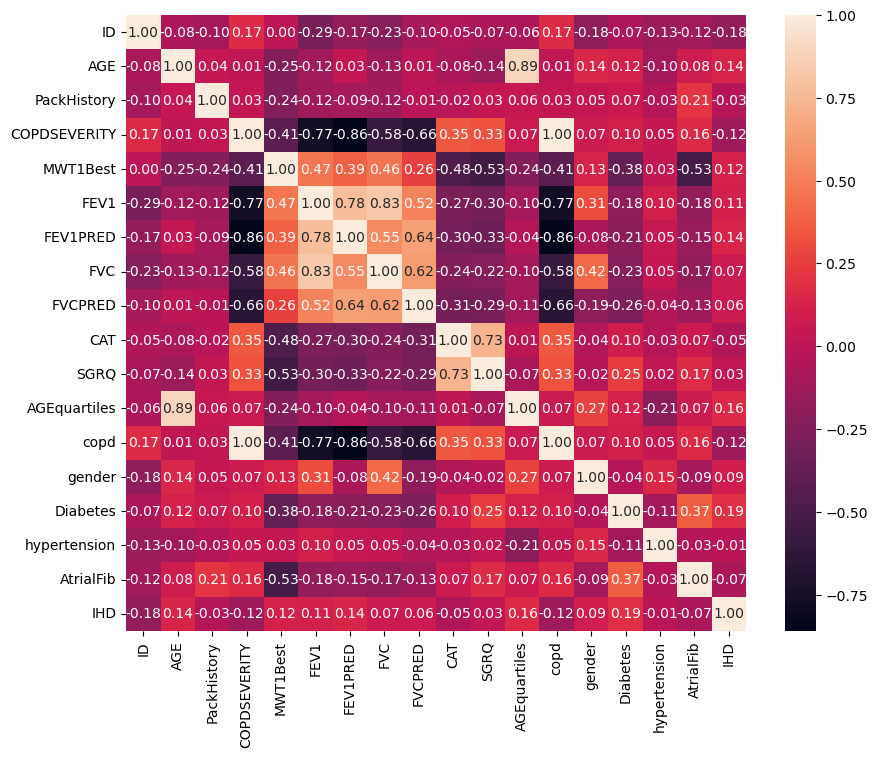

In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(review.corr(),annot=True,cmap='rocket',fmt='.2f')

check the null or empty values

In [39]:
review.isnull().sum()

ID              0
AGE             0
PackHistory     0
COPDSEVERITY    0
MWT1Best        1
FEV1            0
FEV1PRED        0
FVC             0
FVCPRED         0
CAT             0
SGRQ            0
AGEquartiles    0
copd            0
gender          0
Diabetes        0
hypertension    0
AtrialFib       0
IHD             0
dtype: int64

To avoid decreasing the data sample size, I decided to fill the null values with the median of the data. However, this may affect the accuracy of the model because the six-minute walking test is essential for representing exercise tolerance, which is an important assessment for evaluating a patient's cardiopulmonary function.

In [41]:
review.MWT1Best.fillna(review.MWT1Best.median(), inplace=True)

Check whether any null value are left or not

In [43]:
review.isnull().sum()

ID              0
AGE             0
PackHistory     0
COPDSEVERITY    0
MWT1Best        0
FEV1            0
FEV1PRED        0
FVC             0
FVCPRED         0
CAT             0
SGRQ            0
AGEquartiles    0
copd            0
gender          0
Diabetes        0
hypertension    0
AtrialFib       0
IHD             0
dtype: int64

Drop the features that I think have no correlation

In [45]:
columns_to_drop = ["ID"]
review.drop(columns=columns_to_drop, axis=1, inplace=True)

Recheck the data

In [47]:
review

,AGE,PackHistory,COPDSEVERITY,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,CAT,SGRQ,AGEquartiles,copd,gender,Diabetes,hypertension,AtrialFib,IHD
Unnamed: 0,,,,,,,,,,,,,,,,,
1,77,60.0,3,120.0,1.21,36.0,2.40,98,25,69.55,4,3,1,1,0,1,0
2,79,50.0,2,176.0,1.09,56.0,1.64,65,12,44.24,4,2,0,1,0,1,1
3,80,11.0,2,201.0,1.52,68.0,2.30,86,22,44.09,4,2,0,1,0,1,0
4,56,60.0,4,210.0,0.47,14.0,1.14,27,28,62.04,1,4,1,0,1,1,0
5,65,68.0,3,210.0,1.07,42.0,2.91,98,32,75.56,1,3,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,68,25.0,1,575.0,2.70,98.0,3.87,108,20,35.84,2,1,1,0,0,0,0
98,75,40.0,1,577.0,2.90,93.0,4.72,114,9,15.05,3,1,1,0,0,0,1
99,68,30.0,2,582.0,1.65,67.0,2.80,88,4,19.70,2,2,0,0,1,0,0


Split the data into train and test data

In [49]:
X=review.drop(["COPDSEVERITY", "copd"], axis=1) # COPDSEVERITY yields the same results as COPD.
y=review["copd"]

In [50]:
X

,AGE,PackHistory,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,CAT,SGRQ,AGEquartiles,gender,Diabetes,hypertension,AtrialFib,IHD
Unnamed: 0,,,,,,,,,,,,,,,
1,77,60.0,120.0,1.21,36.0,2.40,98,25,69.55,4,1,1,0,1,0
2,79,50.0,176.0,1.09,56.0,1.64,65,12,44.24,4,0,1,0,1,1
3,80,11.0,201.0,1.52,68.0,2.30,86,22,44.09,4,0,1,0,1,0
4,56,60.0,210.0,0.47,14.0,1.14,27,28,62.04,1,1,0,1,1,0
5,65,68.0,210.0,1.07,42.0,2.91,98,32,75.56,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,68,25.0,575.0,2.70,98.0,3.87,108,20,35.84,2,1,0,0,0,0
98,75,40.0,577.0,2.90,93.0,4.72,114,9,15.05,3,1,0,0,0,1
99,68,30.0,582.0,1.65,67.0,2.80,88,4,19.70,2,0,0,1,0,0


In [51]:
y

Unnamed: 0
1      3
2      2
3      2
4      4
5      3
      ..
97     1
98     1
99     2
100    3
101    2
Name: copd, Length: 99, dtype: int64

Perform the split

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
X_train

,AGE,PackHistory,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,CAT,SGRQ,AGEquartiles,gender,Diabetes,hypertension,AtrialFib,IHD
Unnamed: 0,,,,,,,,,,,,,,,
50,71,3.0,420.0,1.67,93.0,2.58,118,21,29.29,3,0,0,0,0,0
73,75,5.0,462.0,2.43,79.0,4.33,107,16,47.88,3,1,0,0,0,0
71,70,36.0,459.0,1.89,90.0,3.51,125,5,10.92,2,0,0,0,0,0
16,71,105.0,271.0,0.72,52.0,2.09,121,12,39.66,2,0,0,0,0,0
40,71,20.0,390.0,1.32,85.0,2.27,119,11,38.43,2,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,73,100.0,451.0,1.26,40.0,2.28,53,23,15.05,3,1,0,0,0,0
74,73,60.0,462.0,1.92,66.0,3.76,98,19,56.96,3,1,0,0,0,1
15,70,103.0,271.0,1.20,52.0,2.09,121,12,39.66,2,0,0,0,0,0


In [55]:
y_train

Unnamed: 0
50    1
73    2
71    1
16    2
40    1
     ..
63    3
74    2
15    2
95    1
52    1
Name: copd, Length: 79, dtype: int64

In [56]:
X_test

,AGE,PackHistory,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,CAT,SGRQ,AGEquartiles,gender,Diabetes,hypertension,AtrialFib,IHD
Unnamed: 0,,,,,,,,,,,,,,,
65,69,47.0,453.0,0.65,60.00,2.29,84,9,28.41,2,0,0,0,0,0
41,78,37.5,391.0,1.60,59.00,2.68,60,5,27.52,4,1,0,0,0,0
98,75,40.0,577.0,2.90,93.00,4.72,114,9,15.05,3,1,0,0,0,1
19,72,15.0,289.0,0.60,24.00,1.81,55,30,38.74,3,1,0,0,0,0
100,54,30.0,699.0,1.72,44.00,4.07,82,10,20.55,1,1,0,0,0,0
87,60,10.0,498.0,1.96,3.29,4.01,96,12,24.52,1,1,0,0,0,0
67,62,80.0,459.0,1.93,61.00,3.39,123,6,10.01,1,0,0,0,1,0
43,67,36.0,400.0,1.79,62.00,3.19,84,23,50.03,2,1,0,0,0,1
11,76,6.0,240.0,1.10,46.00,2.06,75,31,55.56,3,0,1,0,1,0


In [57]:
y_test

Unnamed: 0
65     2
41     2
98     1
19     4
100    3
87     2
67     1
43     2
11     3
1      3
32     3
79     2
48     2
27     3
45     2
5      3
23     3
13     4
91     1
76     1
Name: copd, dtype: int64

#Scaling to ensure that each feature contributes equally to the model

In [59]:
from sklearn.preprocessing import StandardScaler
std = StandardScaler()

In [60]:
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [61]:
X_train_std

array([[ 0.14675193, -1.48918209,  0.20699607, ..., -0.40219983,
        -0.50395263, -0.31180478],
       [ 0.6508129 , -1.40998627,  0.63478364, ..., -0.40219983,
        -0.50395263, -0.31180478],
       [ 0.02073669, -0.18245112,  0.60422738, ..., -0.40219983,
        -0.50395263, -0.31180478],
       ...,
       [ 0.02073669,  2.47060872, -1.31063127, ..., -0.40219983,
        -0.50395263, -0.31180478],
       [-1.86949196, -0.02405949,  1.42924627, ..., -0.40219983,
        -0.50395263,  3.2071349 ],
       [ 0.14675193, -0.81601765,  0.23755232, ...,  2.48632624,
        -0.50395263, -0.31180478]])

In [62]:
X_test_std

array([[-0.10527856,  0.25312587,  0.54311487, -1.44279865,  0.0268997 ,
        -0.66528778, -0.10580179, -1.1724507 , -0.66846471, -0.41167925,
        -1.24434203, -0.48412292, -0.40219983, -0.50395263, -0.31180478],
       [ 1.02885863, -0.12305426, -0.08838107, -0.0087894 , -0.01969263,
        -0.26131623, -1.20800071, -1.70400654, -0.71712877,  1.44675849,
         0.80363756, -0.48412292, -0.40219983, -0.50395263, -0.31180478],
       [ 0.6508129 , -0.02405949,  1.80610675,  1.95353905,  1.5644465 ,
         1.85176573,  1.27194685, -1.1724507 , -1.39897247,  0.51753962,
         0.80363756, -0.48412292, -0.40219983, -0.50395263,  3.2071349 ],
       [ 0.27276717, -1.01400719, -1.12729374, -1.51827282, -1.65042409,
        -1.16248354, -1.43762549,  1.61821746, -0.10363349,  0.51753962,
         0.80363756, -0.48412292, -0.40219983, -0.50395263, -0.31180478],
       [-1.9955072 , -0.42003857,  3.04872778,  0.17234861, -0.71857754,
         1.17847981, -0.1976517 , -1.03956174, 

**Modeling**

Fit in Decision Tree Model

In [64]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train_std, y_train)
# DT.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [65]:
DT.feature_importances_

array([0.06725325, 0.        , 0.        , 0.        , 0.84015676,
       0.03642885, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.05616114, 0.        , 0.        , 0.        ])

In [66]:
y_pred = DT.predict(X_test_std)
# y_pred = DT.predict(X_test)
y_pred

array([2, 2, 1, 4, 3, 4, 2, 2, 3, 3, 3, 2, 2, 3, 1, 3, 3, 3, 2, 1],
      dtype=int64)

Check the accuracy score

In [68]:
from sklearn.metrics import accuracy_score
ac_DT = accuracy_score(y_test, y_pred)
print(f'Accuracy of DT: {ac_DT:.2f}')

Accuracy of DT: 0.75


What's the different between using X_train_std and X_test, they had same prediction rate

Fit in RandomForest model

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

forest_model = RandomForestClassifier(random_state=42)
forest_model.fit(X_train, y_train)
y_pred = forest_model.predict(X_test)

In [72]:
ac_RF = accuracy_score(y_test, y_pred)
print(f'Accuracy of RF: {ac_RF:.2f}')

Accuracy of RF: 0.90


In [73]:
X_test

,AGE,PackHistory,MWT1Best,FEV1,FEV1PRED,FVC,FVCPRED,CAT,SGRQ,AGEquartiles,gender,Diabetes,hypertension,AtrialFib,IHD
Unnamed: 0,,,,,,,,,,,,,,,
65,69,47.0,453.0,0.65,60.00,2.29,84,9,28.41,2,0,0,0,0,0
41,78,37.5,391.0,1.60,59.00,2.68,60,5,27.52,4,1,0,0,0,0
98,75,40.0,577.0,2.90,93.00,4.72,114,9,15.05,3,1,0,0,0,1
19,72,15.0,289.0,0.60,24.00,1.81,55,30,38.74,3,1,0,0,0,0
100,54,30.0,699.0,1.72,44.00,4.07,82,10,20.55,1,1,0,0,0,0
87,60,10.0,498.0,1.96,3.29,4.01,96,12,24.52,1,1,0,0,0,0
67,62,80.0,459.0,1.93,61.00,3.39,123,6,10.01,1,0,0,0,1,0
43,67,36.0,400.0,1.79,62.00,3.19,84,23,50.03,2,1,0,0,0,1
11,76,6.0,240.0,1.10,46.00,2.06,75,31,55.56,3,0,1,0,1,0


In [74]:
onepred = forest_model.predict([[67,45.0,466.0,2.79,88.00,4.11,118,10,29.98,2,1,0,0,0,0]])
onepred



array([1], dtype=int64)

In [75]:
y_test[23]

3

In [76]:
onepred = forest_model.predict([[69,15.0,300.0,0.91,39.00,2.90,105,29,58.78,2,0,0,0,0,0]])
onepred


array([3], dtype=int64)

In [140]:
import pickle

In [142]:
filename = 'copd_model.sav'
pickle.dump(forest_model, open(filename, 'wb'))

In [144]:
# loading the saved model
forest_model = pickle.load(open('copd_model.sav', 'rb'))

In [80]:
# review['copd'].unique()

In [156]:
input_data = [[69,15.0,300.0,0.91,39.00,2.90,105,29,58.78,2,0,0,0,0,0]]

# changing the input_data to numpy array
# input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
# input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = forest_model.predict(input_data)
print(prediction)

if (prediction == 1):
  print('The person has first stage of COPD')
elif (prediction == 2):
  print('The person has second stage of COPD')
elif (prediction == 3):
  print('The person has third stage of COPD')
else:
  print('The person has forth stage of COPD COPD')

[3]
The person has third stage of COPD


In [152]:
# 79	50.0	176.0	1.09	56.0	1.64	65	12	44.24	4	0	1	0	1	1
input_data = [[67,45.0,466.0,2.79,88.00,4.11,118,10,29.98,2,1,0,0,0,0]]

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
# input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = forest_model.predict(input_data)
print(prediction)

if (prediction == 1):
  print('The person has first stage of COPD')
elif (prediction == 2):
  print('The person has second stage of COPD')
elif (prediction == 3):
  print('The person has third stage of COPD')
else:
  print('The person has forth stage of COPD COPD')

[1]
The person has first stage of COPD


In [83]:
# 79	50.0	176.0	1.09	56.0	1.64	65	12	44.24	4	0	1	0	1	1
# input_data = (79,50.0,176.0,1.09,56.0,1.64,65,12,44.24,4,0,1,0,1,1)

# # changing the input_data to numpy array
# input_data_as_numpy_array = np.asarray(input_data)

# # reshape the array as we are predicting for one instance
# input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# prediction = loaded_model.predict(input_data_reshaped)
# print(prediction)

# if (prediction[0] == 0):
#   print('The person has not COPD')
# else:
#   print('The person has COPD')

In [158]:
X.columns

Index(['AGE', 'PackHistory', 'MWT1Best', 'FEV1', 'FEV1PRED', 'FVC', 'FVCPRED',
       'CAT', 'SGRQ', 'AGEquartiles', 'gender', 'Diabetes', 'hypertension',
       'AtrialFib', 'IHD'],
      dtype='object')

In [154]:
for column in X.columns:
  print(column)

AGE
PackHistory
MWT1Best
FEV1
FEV1PRED
FVC
FVCPRED
CAT
SGRQ
AGEquartiles
gender
Diabetes
hypertension
AtrialFib
IHD
